In [51]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

N_ITERS = 5
T_OFFSET = 70
T_OFFSET_IFSTAT = 80
T_END = 30

COL_LABELS = ['30%', '60%', '90%']
ROW_LABELS = ["C-S", "Trickle", "Ours"]

DATA_A_LABEL = "Network Usage (Mbps)"
DATA_B_LABEL = "Peer Discovery Rate (%)"
GROUP_A_COLOR: str = "#020079"
GROUP_B_COLOR: str = "#D38900"

def plot_3x3_dual_axis(data: list[tuple[list[tuple[list[float], list[float]]], list[tuple[list[float], list[float]]]]]):
    if len(data) != 9:
        raise ValueError(f"Expected 9 data entries, got {len(data)}.")
    
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 6,
        "axes.titlesize": 6,
        "axes.labelsize": 6,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "legend.fontsize": 6,
        "figure.titlesize": 6,
    })

    fig, axes = plt.subplots(3, 3, figsize=(3.7, 3.2))
    fig.subplots_adjust(left=0.10, right=0.92, top=0.95, bottom=0.08,
                        hspace=0.15, wspace=0.15)

    axes_left  = []
    axes_right = []

    for idx, ax_left in enumerate(axes.flat):
        row, col = divmod(idx, 3)
        data_a, data_b = data[idx]

        # --- Group A: solid lines, left y-axis ---
        for x, y in data_a:
            ax_left.plot(x, y, color=GROUP_A_COLOR, linewidth=0.5,
                         linestyle="-", alpha=0.03)

        # --- Group B: dashed lines, right y-axis ---
        ax_right = ax_left.twinx()
        for x, y in data_b:
            ax_right.plot(x, y, color=GROUP_B_COLOR, linewidth=2,
                          linestyle="--", alpha=1)

        ax_left.set_ylim(0, 4)
        ax_right.set_ylim(0, 105)
        ax_left.set_xlim(0, T_END)

        ax_left.tick_params(axis="y", labelcolor=GROUP_A_COLOR)
        ax_right.tick_params(axis="y", labelcolor=GROUP_B_COLOR)
        ax_left.tick_params(axis="x")

        # Show Group A tick labels only on leftmost column
        if col != 0:
            ax_left.tick_params(axis="y", labelleft=False)

        # Show Group B tick labels only on rightmost column
        if col != 2:
            ax_right.tick_params(axis="y", labelright=False)

        # x-axis labels only on bottom row
        if row != 2:
            ax_left.tick_params(axis="x", labelbottom=False)

        #ax_left.set_ylabel("")
        #ax_right.set_ylabel("")

        ax_left.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
        ax_left.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax_right.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax_left.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        axes_left.append(ax_left)
        axes_right.append(ax_right)

    # # --- Single legend for both groups ---
    legend_handles = [
        plt.Line2D([0], [0], color=GROUP_A_COLOR, linewidth=2, linestyle="-",  label=DATA_A_LABEL),
        plt.Line2D([0], [0], color=GROUP_B_COLOR, linewidth=2, linestyle="--", label=DATA_B_LABEL),
    ]
    fig.legend(handles=legend_handles, loc="upper right",
               framealpha=0.8, edgecolor="none", bbox_to_anchor=(1, 1.07))

    # --- Column labels at the bottom of each column ---
    for col, label in enumerate(COL_LABELS):
        axes[-1, col].set_xlabel(
            label, 
            family='serif', 
            labelpad=2
        )

    # --- Row labels to the left of each row ---
    for row, label in enumerate(ROW_LABELS):
        axes[row, 0].annotate(
            str(label),
            xy=(0, 0.5), xycoords="axes fraction",
            xytext=(-0.3, 0.5), textcoords="axes fraction",
            family='serif',
            ha="center", va="center",
            rotation=90,
            annotation_clip=False,
        )

    return fig

In [52]:
def read_data(target: str, n_peers: str) -> tuple[list[tuple[list[float], list[float]]], list[tuple[list[float], list[float]]]]:
    n_data = []
    for i in range(N_ITERS):
        for h in range(n_peers):
            time_points = []
            netusages = []
            with open(f'../burst/{target}/{n_peers}/{i}/ifstat_h{h+1}.log', 'r') as f:
                # Skip first two title lines
                next(f, None)
                next(f, None)

                for line_no, line in enumerate(f):
                    execution_time = line_no / 10 - T_OFFSET_IFSTAT
                    netusage = sum([float(v) for v in line.strip().split()])/1000
                    
                    # skip before burst
                    if execution_time < -1.0:
                        continue
                    
                    time_points.append(execution_time)
                    netusages.append(netusage)
            n_data.append((time_points[:(1-10)], np.convolve(netusages, np.ones(10)/10, mode='valid')))
    
    r_data = []
    for i in range(N_ITERS):
        with open(f'../burst/{target}/{n_peers}/r_{i}.txt', 'r') as f:
            time_init = 0
            time_points = []
            reachabilities = []
            
            for line in f:
                parts = line.strip().split()
                if parts[1] == 'N/A':
                    continue

                time = int(parts[0])
                if time_init == 0:
                    time_init = time
                execution_time = (time - time_init) / 1000 - T_OFFSET
                reachability = float(parts[1])
                    
                # skip before burst
                if execution_time < -1.0:
                    continue
                    
                # time interpolation
                if len(time_points) > 0:
                    time_points.append(execution_time)
                    reachabilities.append(reachabilities[-1])
                
                time_points.append(execution_time)
                reachabilities.append(reachability * 100)

            if time_points[-1] < T_END:
                time_points.append(float(T_END))
                reachabilities.append(reachabilities[-1])

            r_data.append((time_points, reachabilities))
    
    return (n_data, r_data)

In [53]:
def read_data_all() -> list[tuple[list[tuple[list[float], list[float]]], list[tuple[list[float], list[float]]]]]:
    return [read_data(target, n_peers) for target in ['client-server', 'dev-eval-trickle', 'dev-v2'] for n_peers in [130, 160, 190] ]

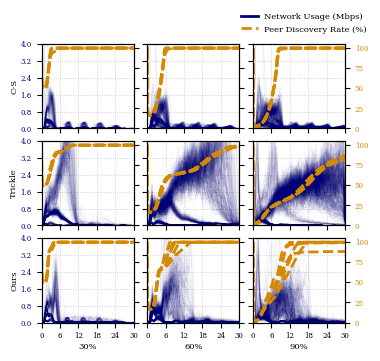

In [54]:
fig = plot_3x3_dual_axis(read_data_all())
fig.savefig("dual_axis_grid.png", dpi=300, bbox_inches="tight", pad_inches=0)

In [55]:
# dummy_data = [
#     (
#         # First element of outer tuple: list[tuple[list[float], list[float]]]
#         [
#             ([10.5, 20.3, 45.0], [88.1, 3.7, 67.2]),
#             ([99.9, 0.1, 55.5], [23.4, 78.6, 11.0]),
#         ],
#         # Second element of outer tuple: list[tuple[list[float], list[float]]]
#         [
#             ([34.2, 61.8, 7.5],  [50.0, 92.3, 18.9]),
#             ([5.5,  43.1, 76.4], [30.0, 14.7, 85.2]),
#         ],
#     ),
#     (
#         [
#             ([0.0,  100.0, 47.3], [63.9, 29.5, 81.1]),
#             ([72.2, 38.8,  14.4], [56.6, 91.0,  2.2]),
#         ],
#         [
#             ([19.9, 44.4, 69.3], [37.7, 58.3, 83.0]),
#             ([6.1,  25.0, 95.5], [40.8, 77.7, 12.3]),
#         ],
#     ),
#     (
#         [
#             ([0.0,  100.0, 47.3], [63.9, 29.5, 81.1]),
#             ([72.2, 38.8,  14.4], [56.6, 91.0,  2.2]),
#         ],
#         [
#             ([19.9, 44.4, 69.3], [37.7, 58.3, 83.0]),
#             ([6.1,  25.0, 95.5], [40.8, 77.7, 12.3]),
#         ],
#     ),
#     (
#         [
#             ([0.0,  100.0, 47.3], [63.9, 29.5, 81.1]),
#             ([72.2, 38.8,  14.4], [56.6, 91.0,  2.2]),
#         ],
#         [
#             ([19.9, 44.4, 69.3], [37.7, 58.3, 83.0]),
#             ([6.1,  25.0, 95.5], [40.8, 77.7, 12.3]),
#         ],
#     ),
#     (
#         [
#             ([0.0,  100.0, 47.3], [63.9, 29.5, 81.1]),
#             ([72.2, 38.8,  14.4], [56.6, 91.0,  2.2]),
#         ],
#         [
#             ([19.9, 44.4, 69.3], [37.7, 58.3, 83.0]),
#             ([6.1,  25.0, 95.5], [40.8, 77.7, 12.3]),
#         ],
#     ),
#     (
#         [
#             ([0.0,  100.0, 47.3], [63.9, 29.5, 81.1]),
#             ([72.2, 38.8,  14.4], [56.6, 91.0,  2.2]),
#         ],
#         [
#             ([19.9, 44.4, 69.3], [37.7, 58.3, 83.0]),
#             ([6.1,  25.0, 95.5], [40.8, 77.7, 12.3]),
#         ],
#     ),
#     (
#         [
#             ([0.0,  100.0, 47.3], [63.9, 29.5, 81.1]),
#             ([72.2, 38.8,  14.4], [56.6, 91.0,  2.2]),
#         ],
#         [
#             ([19.9, 44.4, 69.3], [37.7, 58.3, 83.0]),
#             ([6.1,  25.0, 95.5], [40.8, 77.7, 12.3]),
#         ],
#     ),
#     (
#         [
#             ([0.0,  100.0, 47.3], [63.9, 29.5, 81.1]),
#             ([72.2, 38.8,  14.4], [56.6, 91.0,  2.2]),
#         ],
#         [
#             ([19.9, 44.4, 69.3], [37.7, 58.3, 83.0]),
#             ([6.1,  25.0, 95.5], [40.8, 77.7, 12.3]),
#         ],
#     ),
#     (
#         [
#             ([0.0,  100.0, 47.3], [63.9, 29.5, 81.1]),
#             ([72.2, 38.8,  14.4], [56.6, 91.0,  2.2]),
#         ],
#         [
#             ([19.9, 44.4, 69.3], [37.7, 58.3, 83.0]),
#             ([6.1,  25.0, 95.5], [40.8, 77.7, 12.3]),
#         ],
#     ),
# ]
# fig = plot_3x3_dual_axis(dummy_data)
# fig.savefig("dual_axis_grid.png", dpi=150, bbox_inches="tight")